# Association Rule Mining C1 — Streaming Series

## Role 1: Setup, EDA and Transaction Building

This section prepares the streaming series dataset for Association Rule Mining. 
It covers initial exploratory data analysis, construction of viewing-session 
transactions, basket-size analysis, and creation of a separate show lookup table.

In [1]:
import pandas as pd
import numpy as np

pd.set_option("display.max_columns", None)

In [2]:
df = pd.read_csv("../data/streaming_series_watched.csv")

df.head()

,ls dataviewing_session_id,transaction_date,show_id,item_name,category,avg_episode_minutes
0,1,2025-05-07,S05,Office Antics,Sitcom,22
1,1,2025-05-07,S02,The Detective,Crime Drama,50
2,1,2025-05-07,S08,Time Anomaly,Sci-Fi,48
3,2,2025-06-11,S04,Laugh Track,Sitcom,25
4,2,2025-06-11,S05,Office Antics,Sitcom,22


## 1. Exploratory Data Analysis (EDA)

The first step is to inspect the structure, dimensions, data types, missing values, and basic characteristics of the streaming-series dataset.

In [3]:
# Dataset dimensions
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

# Column names
print("\nColumns:")
print(df.columns.tolist())

# Data types and non-null counts
print("\nDataset Information:")
df.info()

Number of rows: 8035
Number of columns: 6

Columns:
['ls dataviewing_session_id', 'transaction_date', 'show_id', 'item_name', 'category', 'avg_episode_minutes']

Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 8035 entries, 0 to 8034
Data columns (total 6 columns):
 #   Column                     Non-Null Count  Dtype
---  ------                     --------------  -----
 0   ls dataviewing_session_id  8035 non-null   int64
 1   transaction_date           8035 non-null   str  
 2   show_id                    8035 non-null   str  
 3   item_name                  8035 non-null   str  
 4   category                   8035 non-null   str  
 5   avg_episode_minutes        8035 non-null   int64
dtypes: int64(2), str(4)
memory usage: 376.8 KB


In [4]:
# Missing values
print("Missing values per column:")
display(df.isnull().sum())

# Duplicate rows
print("\nNumber of duplicate rows:", df.duplicated().sum())

Missing values per column:


ls dataviewing_session_id    0
transaction_date             0
show_id                      0
item_name                    0
category                     0
avg_episode_minutes          0
dtype: int64


Number of duplicate rows: 0


In [6]:
print(df.columns.tolist())

['ls dataviewing_session_id', 'transaction_date', 'show_id', 'item_name', 'category', 'avg_episode_minutes']


In [7]:
df.columns = df.columns.str.strip()

print(df.columns.tolist())

['ls dataviewing_session_id', 'transaction_date', 'show_id', 'item_name', 'category', 'avg_episode_minutes']


In [9]:
df = df.rename(columns={
    "ls dataviewing_session_id": "viewing_session_id"
})

print(df.columns.tolist())

['viewing_session_id', 'transaction_date', 'show_id', 'item_name', 'category', 'avg_episode_minutes']


In [10]:
df.head()

,viewing_session_id,transaction_date,show_id,item_name,category,avg_episode_minutes
0,1,2025-05-07,S05,Office Antics,Sitcom,22
1,1,2025-05-07,S02,The Detective,Crime Drama,50
2,1,2025-05-07,S08,Time Anomaly,Sci-Fi,48
3,2,2025-06-11,S04,Laugh Track,Sitcom,25
4,2,2025-06-11,S05,Office Antics,Sitcom,22


In [11]:
df["transaction_date"] = pd.to_datetime(df["transaction_date"])

print("Total records:", len(df))
print("Unique viewing sessions:", df["viewing_session_id"].nunique())
print("Unique shows:", df["show_id"].nunique())
print("Unique item names:", df["item_name"].nunique())
print("Unique transaction dates:", df["transaction_date"].nunique())

print("\nEarliest transaction date:", df["transaction_date"].min())
print("Latest transaction date:", df["transaction_date"].max())

Total records: 8035
Unique viewing sessions: 3500
Unique shows: 15
Unique item names: 15
Unique transaction dates: 181

Earliest transaction date: 2025-01-01 00:00:00
Latest transaction date: 2025-06-30 00:00:00


In [12]:
basket_sizes = df.groupby("viewing_session_id")["show_id"].nunique()

basket_sizes.describe()

count    3500.000000
mean        2.295714
std         0.847459
min         1.000000
25%         2.000000
50%         2.000000
75%         3.000000
max         4.000000
Name: show_id, dtype: float64

### Basket Size Distribution

A basket represents the unique shows watched during one viewing session. 
The basket-size distribution shows how many sessions contain one, two, three, or more unique shows.

In [13]:
basket_size_distribution = (
    basket_sizes
    .value_counts()
    .sort_index()
    .rename_axis("basket_size")
    .reset_index(name="number_of_sessions")
)

basket_size_distribution

,basket_size,number_of_sessions
0,1,513
1,2,1818
2,3,790
3,4,379


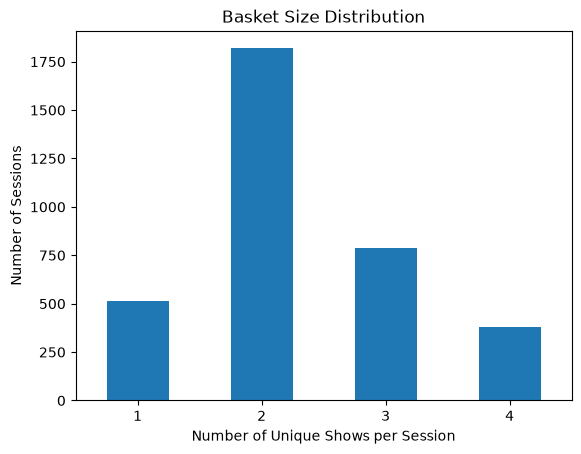

In [14]:
import matplotlib.pyplot as plt

basket_size_distribution.plot(
    x="basket_size",
    y="number_of_sessions",
    kind="bar",
    legend=False
)

plt.title("Basket Size Distribution")
plt.xlabel("Number of Unique Shows per Session")
plt.ylabel("Number of Sessions")
plt.xticks(rotation=0)
plt.show()

## 2. Show Lookup Table

A separate lookup table is created to retain descriptive information about each show. 
This allows the transaction baskets to contain only show identifiers while show names, 
categories, and average episode runtimes remain available for interpretation.

In [15]:
show_lookup = (
    df[
        ["show_id", "item_name", "category", "avg_episode_minutes"]
    ]
    .drop_duplicates()
    .sort_values("show_id")
    .reset_index(drop=True)
)

show_lookup

,show_id,item_name,category,avg_episode_minutes
0,S01,Crime City,Crime Drama,45
1,S02,The Detective,Crime Drama,50
2,S03,Silent Witness Redux,Crime Drama,42
3,S04,Laugh Track,Sitcom,25
4,S05,Office Antics,Sitcom,22
5,S06,Space Frontier,Sci-Fi,55
6,S07,Galactic Wars,Sci-Fi,60
7,S08,Time Anomaly,Sci-Fi,48
8,S09,Toon Town,Kids,20
9,S10,Little Explorers,Kids,18


In [16]:
print("Number of unique shows:", df["show_id"].nunique())
print("Rows in lookup table:", len(show_lookup))
print("Duplicate show IDs:", show_lookup["show_id"].duplicated().sum())

Number of unique shows: 15
Rows in lookup table: 15
Duplicate show IDs: 0


## 3. Building Transactions

For Association Rule Mining, the dataset is transformed from individual viewing records 
into transaction baskets. Each `viewing_session_id` represents one transaction, and the 
shows watched during that session form the items in the basket.

`transaction_date` is not included in the baskets because the association analysis focuses 
on combinations of shows watched within the same session.

In [17]:
transactions = (
    df.groupby("viewing_session_id")["show_id"]
      .apply(lambda x: sorted(x.unique()))
      .reset_index(name="basket")
)

transactions.head(10)

,viewing_session_id,basket
0,1,"[S02, S05, S08]"
1,2,"[S04, S05]"
2,3,"[S01, S02, S03]"
3,4,"[S09, S14]"
4,5,"[S07, S12]"
5,6,"[S01, S04, S05]"
6,7,"[S11, S12]"
7,8,"[S09, S10]"
8,9,"[S09, S10]"
9,10,[S02]


In [18]:
["viewing_session_id", "show_id"]

['viewing_session_id', 'show_id']

In [19]:
print("Original viewing records:", len(df))
print("Number of transaction baskets:", len(transactions))
print("Unique viewing sessions:", df["viewing_session_id"].nunique())

transactions.head()

Original viewing records: 8035
Number of transaction baskets: 3500
Unique viewing sessions: 3500


,viewing_session_id,basket
0,1,"[S02, S05, S08]"
1,2,"[S04, S05]"
2,3,"[S01, S02, S03]"
3,4,"[S09, S14]"
4,5,"[S07, S12]"


## 4. Transaction Validation

The prepared transactions are validated to ensure that each viewing session corresponds 
to exactly one basket and that no transaction dates or descriptive attributes are included 
in the baskets.

In [20]:
print("Unique viewing sessions:", df["viewing_session_id"].nunique())
print("Transaction baskets:", len(transactions))
print("Unique shows:", df["show_id"].nunique())
print("Lookup table rows:", len(show_lookup))

assert len(transactions) == df["viewing_session_id"].nunique()
assert len(show_lookup) == df["show_id"].nunique()

print("\nValidation successful.")

Unique viewing sessions: 3500
Transaction baskets: 3500
Unique shows: 15
Lookup table rows: 15

Validation successful.


In [21]:
show_lookup.to_csv("../outputs/show_lookup.csv", index=False)

In [22]:
transactions_export = transactions.copy()

transactions_export["basket"] = transactions_export["basket"].apply(
    lambda items: ",".join(items)
)

transactions_export.to_csv(
    "../outputs/session_transactions.csv",
    index=False
)

print("Files saved successfully.")

Files saved successfully.


In [23]:
import os

print(os.listdir("../outputs"))

['session_transactions.csv', 'show_lookup.csv']


## Role 1 Summary

The streaming-series dataset was successfully loaded and prepared for Association Rule Mining. 
Initial EDA was conducted to examine the dataset dimensions, viewing sessions, unique shows, 
transaction dates, missing values, duplicates, and basket-size distribution.

The data was then transformed into transaction baskets by grouping records according to 
`viewing_session_id`, with each session representing one basket of unique `show_id` values. 
`transaction_date` was excluded from the transaction baskets because it is not required for 
the association analysis.

A separate show lookup table was also created containing `show_id`, `item_name`, `category`, 
and `avg_episode_minutes`. The prepared transaction and lookup datasets were saved for use in 
the subsequent Association Rule Mining stages.